---
title: "Two-Step Floating Catchment Area (2SFCA) Accessibility"
toc: true
execute:
  enabled: true
image: image.png
---

Binary threshold coverage (see the [coverage metrics example](../coverage_metrics/index.ipynb)) answers "is this region within X minutes of a site?" -- but it treats every region within the threshold identically, regardless of how many other regions are competing for the same site's supply.

The **two-step floating catchment area (2SFCA)** method fixes that. For each site, it computes a supply-to-demand ratio over everyone within reach of it (step 1), then for each demand region, sums the ratios of every site reachable from it (step 2). Two regions with the same travel time to their nearest site can end up with very different accessibility if one of them shares that site with far more competing demand, or has fewer other sites within reach.

`two_step_floating_catchment()` is available on both `SiteProblem` (scoring any set of sites directly, with no `solve()` required) and `SiteSolutionSet` (scoring one chosen solution's selected sites) -- this example mostly uses the former, since it's useful even before optimising anything. With no `site_names`/`site_indices`, it scores every registered candidate site; pass the subset you want explicitly (e.g. only the sites already open) if your candidate pool also includes proposed sites that aren't built yet.

## Setting up the problem

Same demand, sites, travel matrix and region geometry as the [coverage metrics example](../coverage_metrics/index.ipynb), so the two examples are directly comparable. 2SFCA additionally needs a **supply** figure per site -- e.g. GP full-time-equivalent staff, beds, or weekly appointment slots. The Brighton sample dataset has no real staffing data, so we add an illustrative `gp_fte` column here for demonstration; `supply_col` is named at call time rather than registered via `add_sites()`, so the same problem could equally be scored under a different supply definition (e.g. `beds`) without re-adding sites.

In [1]:
import geopandas as gpd
from lokigi.site import SiteProblem

sites_gdf = gpd.read_file("../../../sample_data/brighton_sites_named.geojson")

# Illustrative GP staffing (FTE) -- made up for demonstration, since the
# sample dataset has no real capacity data.
sites_gdf["gp_fte"] = [4, 2, 8, 3, 5, 6]

problem = SiteProblem()

problem.add_demand(
    "../../../sample_data/brighton_demand.csv",
    demand_col="demand",
    location_id_col="LSOA"
    )

problem.add_sites(
    sites_gdf,
    candidate_id_col="site"
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving_named.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )

problem.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

## Baseline accessibility -- no `solve()` required

`two_step_floating_catchment()` can score all six candidate sites directly, with no `solve()` needed. Here every candidate genuinely represents a site that's already open, so "all six" and "the current network" happen to coincide -- that's a property of this dataset, not something the method assumes; if your own candidate pool also includes proposed-but-unbuilt sites, pass `site_names`/`site_indices` for just the open ones. We use an 8-minute `catchment_size`, matching the coverage example's `threshold_for_coverage` so the two are comparable.

In [2]:
region_accessibility = problem.two_step_floating_catchment(
    supply_col="gp_fte",
    catchment_size=8,
    )

region_accessibility.sort_values("accessibility").head()

,accessibility,n_sites_in_catchment,demand
LSOA,,,
Brighton and Hove 027F,0.0,0,2323
Brighton and Hove 002B,0.0,0,2665
Brighton and Hove 033A,0.0,0,929
Brighton and Hove 033E,0.0,0,1406
Brighton and Hove 033B,0.0,0,1035


`accessibility` is GP FTE per head available within reach of each region (here, ordered lowest-first); `n_sites_in_catchment` is how many of the six sites are within 8 minutes; `demand` is echoed from `add_demand()` for weighting downstream.

## Where 2SFCA disagrees with coverage

To compare directly against binary coverage, we evaluate the same six-site network with `evaluate_single_solution_single_objective()` and an 8-minute `threshold_for_coverage`, then join its per-region `min_cost`/`within_threshold` columns to the accessibility table above.

In [3]:
evaluated = problem.evaluate_single_solution_single_objective(
    objective="p_median",
    site_names=sites_gdf["site"].tolist(),
    threshold_for_coverage=8,
    )

comparison = (
    evaluated.show_result_df()
    .set_index("LSOA")[["min_cost", "within_threshold"]]
    .join(region_accessibility[["accessibility"]])
    )

comparison.head()

,min_cost,within_threshold,accessibility
LSOA,,,
Brighton and Hove 027E,7.404833,True,0.000060
Brighton and Hove 027F,8.318500,False,0.000000
Brighton and Hove 027A,6.840000,True,0.000024
Brighton and Hove 029E,6.328667,True,0.000024
Brighton and Hove 029D,5.216667,True,0.000024


In [4]:
covered = comparison[comparison["within_threshold"]]

lowest_access = covered.sort_values("accessibility").iloc[0]
highest_access = covered.sort_values("accessibility").iloc[-1]

lowest_access, highest_access

(min_cost                6.84
 within_threshold        True
 accessibility       0.000024
 Name: Brighton and Hove 027A, dtype: object,
 min_cost            3.995833
 within_threshold        True
 accessibility       0.000209
 Name: Brighton and Hove 011D, dtype: object)

Both of these regions are "covered" under the binary metric (min_cost < 8 minutes), but their 2SFCA accessibility differs by almost 8.8x: Brighton and Hove 027A sits at 6.84 minutes with an accessibility of 0.000024 GP FTE per head, while Brighton and Hove 011D is closer still (4.00 minutes) *and* far better served, at 0.000209 GP FTE per head. Coverage alone cannot distinguish these two cases; 2SFCA can. 153 of the 165 regions are "covered" at this threshold, so this is a genuine, common case, not an edge case.

## Visualising the disagreement

Plotting every region's travel time to its nearest site against its 2SFCA accessibility, coloured by whether it meets the coverage threshold, makes the blind spot visible directly: points to the left of the dashed line are all "covered" by the binary metric, yet spread across a wide range of accessibility.

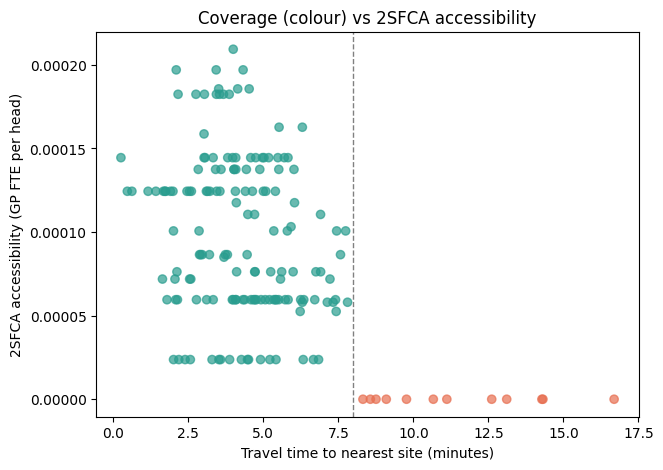

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
colors = comparison["within_threshold"].map({True: "#2a9d8f", False: "#e76f51"})
ax.scatter(comparison["min_cost"], comparison["accessibility"], c=colors, alpha=0.7)
ax.axvline(8, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Travel time to nearest site (minutes)")
ax.set_ylabel("2SFCA accessibility (GP FTE per head)")
ax.set_title("Coverage (colour) vs 2SFCA accessibility")
plt.show()

Every green point is "covered" by the binary metric, but they are not equally well served -- some sit near the bottom of the accessibility range because they share a popular site with a lot of competing demand.

## Inspecting the supply side

`return_site_ratios=True` also returns the step-1 per-site table, useful for finding which site is driving an implausible regional score.

In [6]:
_, site_ratios = problem.two_step_floating_catchment(
    supply_col="gp_fte",
    catchment_size=8,
    return_site_ratios=True,
    )

site_ratios.sort_values("ratio")

,supply,catchment_demand,n_regions_in_catchment,ratio
site,,,,
Daisy (Site 4),3,126472.0,66,0.000024
Begonia (Site 2),2,74219.0,44,0.000027
Dahlia (Site 1),4,83042.0,47,0.000048
Snowdrop (Site 6),6,114238.0,71,0.000053
Daffodil (Site 5),5,86171.0,50,0.000058
Tulip (Site 3),8,134366.0,59,0.000060


A low `ratio` means that site's supply is spread thin over a lot of catchment demand; a high one means it is relatively uncontested. A region's `accessibility` is the sum of the ratios of every site it can reach, so being near a low-`ratio` site (even alone) can leave a region worse off than being near several higher-`ratio` ones.

## Scoring a proposed (smaller) solution

`SiteSolutionSet.two_step_floating_catchment()` takes the same solution-selection arguments as `site_allocation_summary()`, so a chosen solution's accessibility can be compared against the six-site baseline above.

In [7]:
solutions = problem.solve(
    objectives="mclp",
    p=2,
    threshold_for_coverage=8
    )

two_site_accessibility = solutions.two_step_floating_catchment(
    supply_col="gp_fte",
    catchment_size=8,
    solution_rank=1,
    )

two_site_accessibility.sort_values("accessibility").head()

  0%|          | 0/15 [00:00<?, ?it/s]

,accessibility,n_sites_in_catchment,demand
LSOA,,,
Brighton and Hove 027F,0.0,0,2323
Brighton and Hove 003C,0.0,0,300
Brighton and Hove 011B,0.0,0,1021
Brighton and Hove 011E,0.0,0,1256
Brighton and Hove 004D,0.0,0,990


Dropping from six sites to the two MCLP selects (Tulip and Daisy) more than triples the number of regions with **no** site in `catchment_size` at all -- from 12 out of 165 to 42 -- and roughly triples typical accessibility scarcity: mean accessibility falls from about 9.2e-05 to about 3.1e-05 GP FTE per head. This tracks the conservation property noted in the method's docstring -- summed demand-weighted accessibility equals total supply among sites with a non-empty catchment (28 GP FTE across all six sites vs. 11 across just Tulip and Daisy) -- so a smaller network has less total supply to spread around, on top of any individual region losing its nearest site outright.

`plot_accessibility()` puts the two tables above on a map directly: a region choropleth of `accessibility`, overlaid with site markers. By default markers are plain location dots (deliberately not coloured/sized by anything, since that reads too easily as a raw capacity metric); passing `show_site_ratio=True` below instead colours and sizes them by their step-1 `ratio` (red and small for an overloaded site, green and large for a relatively uncontested one). Like `two_step_floating_catchment()` itself, it needs no `solve()` -- called on `problem`, it scores every candidate site; called on a `SiteSolutionSet`, it scores that solution's selected sites.

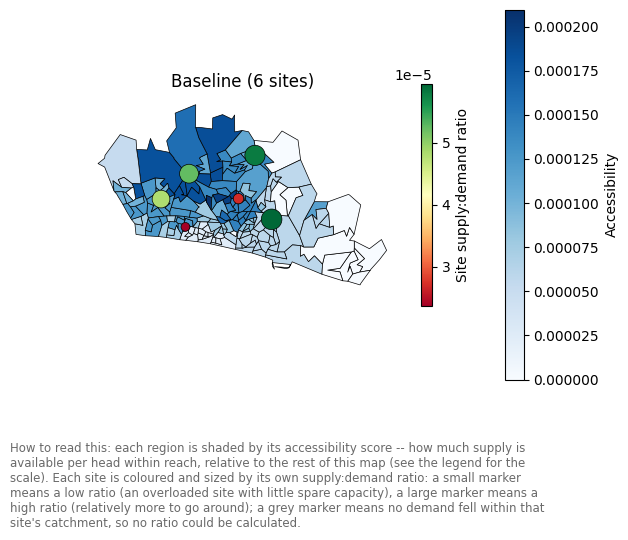

In [8]:
problem.plot_accessibility(
    supply_col="gp_fte",
    catchment_size=8,
    show_site_ratio=True,
    add_basemap=False,
    title="Baseline (6 sites)",
    );

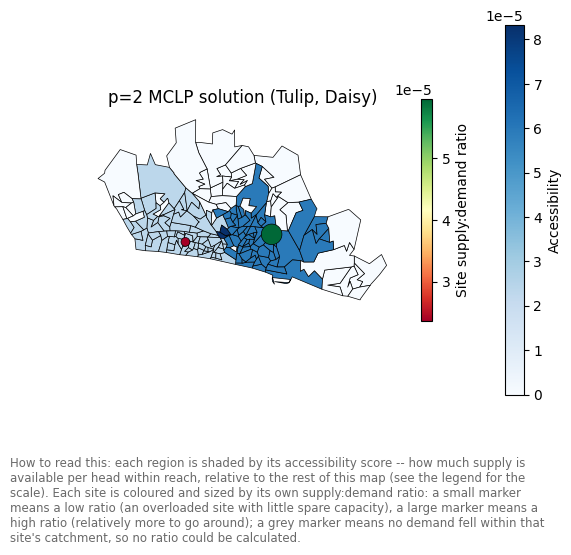

In [9]:
solutions.plot_accessibility(
    supply_col="gp_fte",
    catchment_size=8,
    show_site_ratio=True,
    add_basemap=False,
    title="p=2 MCLP solution (Tulip, Daisy)",
    );

With six sites, Tulip (the highest-`ratio`, largest green marker in the site-ratio table above) sits in an area that already reads as high-accessibility on the map. Dropping to the two-site solution visibly shrinks the high-accessibility area around it, and Daisy -- the *lowest*-ratio site -- now has to cover a much wider area alone, consistent with the mean-accessibility drop already noted above.

`interactive=True` returns the same two layers as a Folium map, with a tooltip on every region and site.

## Enhanced 2SFCA (distance decay)

A single hard `catchment_size` treats a site 1 minute away identically to one 8 minutes away, as long as both are under the cutoff, and identically to "unreachable" for a site 9 minutes away. Enhanced 2SFCA (E2SFCA, Luo & Qi 2009) softens this with step-decay bands: `distance_decay=[(upper_bound, weight), ...]`. A closer band counts for more, and the last band's `upper_bound` becomes the effective catchment edge -- `catchment_size=8` is exactly the single-band case `distance_decay=[(8, 1.0)]`.

The bands below (breaks at 4/8/12 minutes) are scaled to match this example's existing 8-minute baseline, not copied from the paper. Luo & Qi's own published zones are 0-10/10-20/20-30 minutes, with two named weight sets: `[(10, 1.0), (20, 0.68), (30, 0.22)]` ("weight set 1", slower decay) and `[(10, 1.0), (20, 0.42), (30, 0.09)]` ("weight set 2", their preferred, sharper decay) -- real published values, not arbitrary illustrations, used elsewhere in this library's own docstrings.

In [10]:
region_step_decay = problem.two_step_floating_catchment(
    supply_col="gp_fte",
    distance_decay=[(4, 1.0), (8, 0.6), (12, 0.25)],
    )

region_step_decay.sort_values("accessibility").head()

,accessibility,n_sites_in_catchment,demand
LSOA,,,
Brighton and Hove 033E,0.0,0,1406
Brighton and Hove 033A,0.0,0,929
Brighton and Hove 009E,0.0,0,2457
Brighton and Hove 033B,0.0,0,1035
Brighton and Hove 009A,0.0,0,2883


Widening the catchment out to 12 minutes (with decreasing weight) reaches more sites per region than the hard 8-minute cutoff did, but each further-away site now contributes less than a close one instead of counting the same as one right next door.

A continuous alternative is Gaussian decay (Dai 2010): rather than discrete bands, weight falls off smoothly with distance, reaching exactly 0 at the truncation radius (`catchment_size` inside the spec) rather than dropping in steps.

```python
distance_decay={"method": "gaussian", "catchment_size": 12, "bandwidth": 6}
```

In [11]:
region_gaussian = problem.two_step_floating_catchment(
    supply_col="gp_fte",
    distance_decay={"method": "gaussian", "catchment_size": 12, "bandwidth": 6},
    )

region_gaussian.sort_values("accessibility").head()

,accessibility,n_sites_in_catchment,demand
LSOA,,,
Brighton and Hove 033E,0.0,0,1406
Brighton and Hove 033A,0.0,0,929
Brighton and Hove 009E,0.0,0,2457
Brighton and Hove 033B,0.0,0,1035
Brighton and Hove 009A,0.0,0,2883


In [12]:
import pandas as pd

pd.DataFrame(
    {
        "hard cutoff (8 min)": [
            region_accessibility["accessibility"].mean(),
            (region_accessibility["accessibility"] == 0).sum(),
        ],
        "step decay (bands to 12 min)": [
            region_step_decay["accessibility"].mean(),
            (region_step_decay["accessibility"] == 0).sum(),
        ],
        "gaussian decay (radius 12 min)": [
            region_gaussian["accessibility"].mean(),
            (region_gaussian["accessibility"] == 0).sum(),
        ],
    },
    index=["mean accessibility", "regions with zero accessibility"],
)

,hard cutoff (8 min),step decay (bands to 12 min),gaussian decay (radius 12 min)
mean accessibility,0.000092,0.00009,0.000092
regions with zero accessibility,12.000000,5.00000,5.000000


The plain mean isn't quite the right thing to compare here -- the *demand-weighted* mean (`sum(demand * accessibility) / sum(demand)`) is exactly conserved across all three, since it always equals `sum(supply) / sum(demand)` regardless of how the catchment is defined (the conservation invariant from the baseline section above). What genuinely differs is *how many regions are reached at all*: the wider effective reach of both decay-based catchments (12 minutes, vs. the hard cutoff's 8) more than halves the number of regions with zero accessibility.

## Elsewhere in lokigi

- `site_allocation_summary()` answers a related but different question -- how much *demand* is closest to each selected site, with no competition/overlap modelling. See the note in its own documentation about it being the nearest-provider special case of a floating catchment.
- 2SFCA here is descriptive only: it does not feed into `solution_df`, `rank_on=`, or any `solve()` objective -- a natural follow-up.
- See the [coverage metrics example](../coverage_metrics/index.ipynb) for the demand-weighted vs. region-counted distinction in the binary coverage metrics this example contrasts with.
- See the [site utilisation example](../site_utilisation/index.ipynb) for a different, solve-independent question: whether a site is already full *today*, using only real-world current-load/capacity data registered on `candidate_sites` -- no travel matrix, no demand data, and no competition/overlap modelling at all.